# Marketing Mix Modelling 

in this project, I analyse marketing spends data and try to understand its relationship with sales for that calendar week. Using insights from said analyses, I will build a forecasting model

## Data Loading and prerequisites

In [80]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv('../data/Raw/Sample Media Spend Data.csv')

In [82]:
df.head()

,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,1/6/2018,392,422,408,349895.0107,73580,12072,682,59417
1,A,1/13/2018,787,904,110,506270.2176,11804,9499,853,56806
2,A,1/20/2018,81,970,742,430042.1538,52232,17048,759,48715
3,A,1/27/2018,25,575,65,417745.6658,78640,10207,942,72047
4,A,2/3/2018,565,284,295,408505.8012,40561,5834,658,56235


In [83]:
df.tail()

,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
3046,Z,2/1/2020,29239,25311,622406,1.459071e+06,45026,12098,53667,82707
3047,Z,2/8/2020,26230,28031,624409,5.342505e+05,227070,9548,53665,84503
3048,Z,2/15/2020,24749,31281,439362,4.227182e+05,393685,9861,55561,147325
3049,Z,2/22/2020,20713,30356,464178,6.085799e+05,424676,10221,49221,111525
3050,Z,2/29/2020,15990,26993,449032,4.390165e+05,161439,10294,42994,98187


In [84]:
df.shape

(3051, 10)

In [85]:
df.columns

Index(['Division', 'Calendar_Week', 'Paid_Views', 'Organic_Views',
       'Google_Impressions', 'Email_Impressions', 'Facebook_Impressions',
       'Affiliate_Impressions', 'Overall_Views', 'Sales'],
      dtype='object')

In [86]:
df.dtypes

Division                  object
Calendar_Week             object
Paid_Views                 int64
Organic_Views              int64
Google_Impressions         int64
Email_Impressions        float64
Facebook_Impressions       int64
Affiliate_Impressions      int64
Overall_Views              int64
Sales                      int64
dtype: object

In [87]:
df.columns = map(str.lower, df.columns)

In [88]:
df.columns

Index(['division', 'calendar_week', 'paid_views', 'organic_views',
       'google_impressions', 'email_impressions', 'facebook_impressions',
       'affiliate_impressions', 'overall_views', 'sales'],
      dtype='object')

### Variable Identification and Typecasting

In [89]:
df.dtypes

division                  object
calendar_week             object
paid_views                 int64
organic_views              int64
google_impressions         int64
email_impressions        float64
facebook_impressions       int64
affiliate_impressions      int64
overall_views              int64
sales                      int64
dtype: object

calendar_week is here as a string, but will be converted to date time


In [90]:
#identify variables with integer datatype 
df.dtypes[df.dtypes == 'int64']

paid_views               int64
organic_views            int64
google_impressions       int64
facebook_impressions     int64
affiliate_impressions    int64
overall_views            int64
sales                    int64
dtype: object

Summary: 
* paid_views and organic views, these represent the amount of youtube paid and organic views, remains an integer 
* Google impressions, facebook impressions, affiliate impressions: these account for the number of impressions gained by various channels, hence will remain an integer
* Overall_views accounts for the total amount of views from all channels, remains an integer 
* Sales: Total amount of sales gotten, remains an integer

In [91]:
#Identifying variables with float datatype 
df.dtypes[df.dtypes == 'float64']

email_impressions    float64
dtype: object

Summary: 
* email_impressions: These are the amount of impressions gotten via email, will be converted to an integer

In [92]:
df['email_impressions'].isna().value_counts()

email_impressions
False    3051
Name: count, dtype: int64

In [93]:
df['email_impressions'] 

0       3.498950e+05
1       5.062702e+05
2       4.300422e+05
3       4.177457e+05
4       4.085058e+05
            ...     
3046    1.459071e+06
3047    5.342505e+05
3048    4.227182e+05
3049    6.085799e+05
3050    4.390165e+05
Name: email_impressions, Length: 3051, dtype: float64

In [94]:
df['email_impressions'] = np.round(df['email_impressions'], decimals = 1)
df['email_impressions'] = df['email_impressions'].astype(int)

In [95]:
#Identifying variables with str datatype
df.dtypes[df.dtypes == 'str']

Series([], dtype: object)

Summary: 
* division: Alphabetical delineation between company divisions, remains as string 
* calendar_week: represents the first day of the week, will be converted to datetime

In [96]:
df['calendar_week'] = pd.to_datetime(df['calendar_week'])

In [97]:
df['calendar_week'].dtype

dtype('<M8[ns]')

In [98]:
df.head()

,division,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales
0,A,2018-01-06,392,422,408,349895,73580,12072,682,59417
1,A,2018-01-13,787,904,110,506270,11804,9499,853,56806
2,A,2018-01-20,81,970,742,430042,52232,17048,759,48715
3,A,2018-01-27,25,575,65,417745,78640,10207,942,72047
4,A,2018-02-03,565,284,295,408505,40561,5834,658,56235


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3051 entries, 0 to 3050
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   division               3051 non-null   object        
 1   calendar_week          3051 non-null   datetime64[ns]
 2   paid_views             3051 non-null   int64         
 3   organic_views          3051 non-null   int64         
 4   google_impressions     3051 non-null   int64         
 5   email_impressions      3051 non-null   int64         
 6   facebook_impressions   3051 non-null   int64         
 7   affiliate_impressions  3051 non-null   int64         
 8   overall_views          3051 non-null   int64         
 9   sales                  3051 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 238.5+ KB


## Univariate Analysis 

In [100]:
numerical_columns = df.dtypes[df.dtypes == 'int64'].index.tolist()

In [101]:
def plot_numerical_columns(column):
        df[column].describe()
        plt.figure(figsize = (8,4))
        plt.subplot(1,2,1)
        sns.histplot(df[column], kde = True)
        plt.title(f'Histogram (Shape): {column}')

        plt.subplot(1,2,2)
        sns.boxplot(y = df[column])
        plt.title(f'Box Plot (Outliers): {column}')

        plt.tight_layout()
        plt.show()


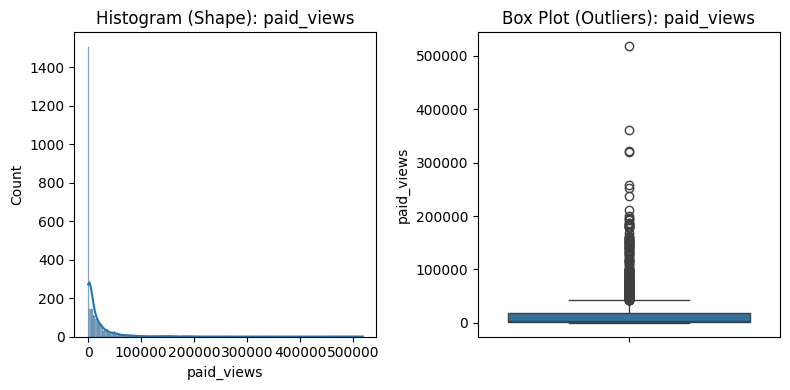

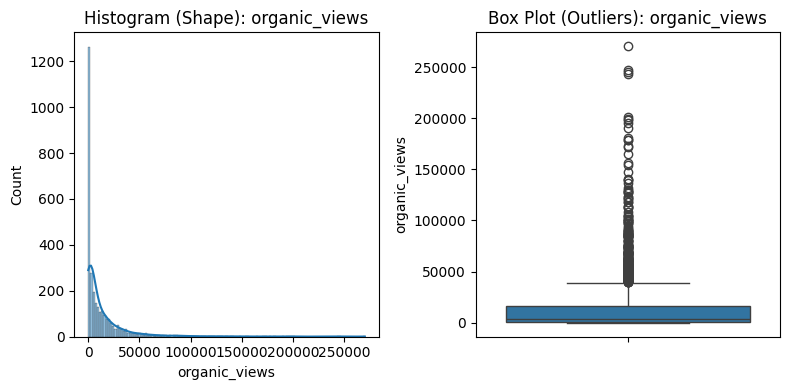

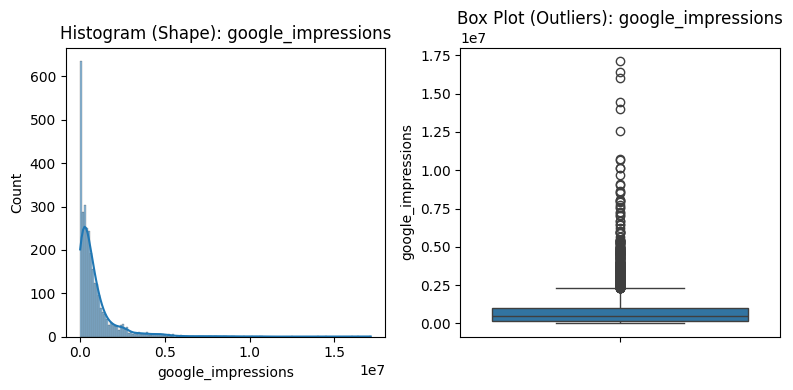

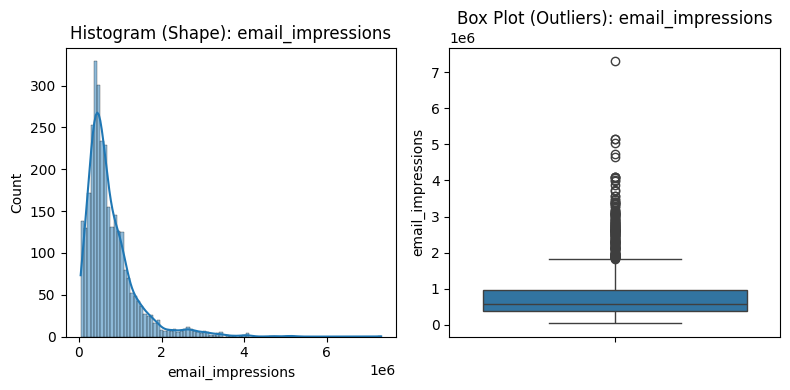

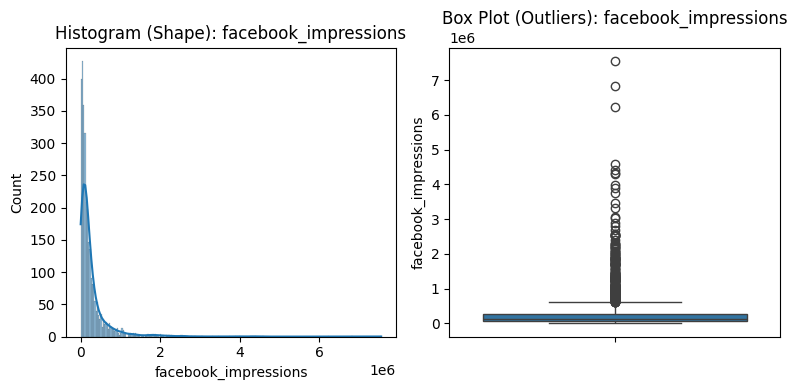

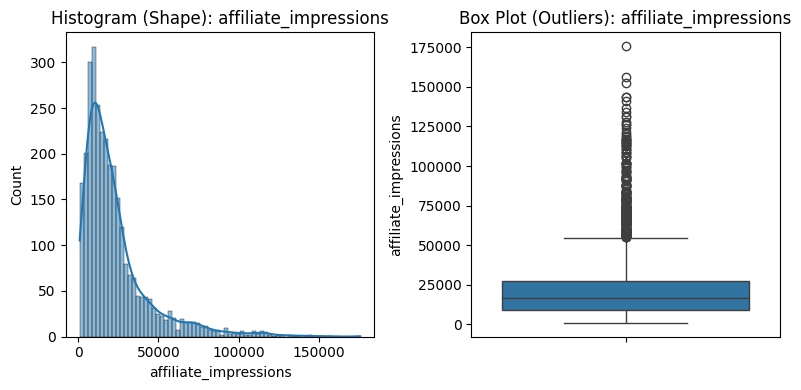

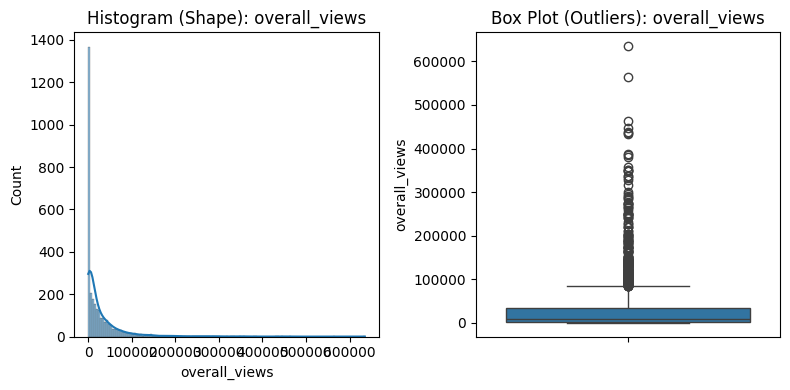

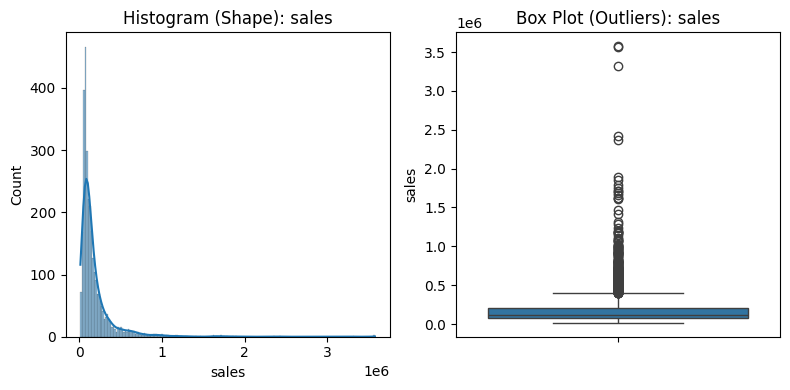

In [102]:
for column in numerical_columns:
    plot_numerical_columns(column)

### Observation:

In all the plots, there exists distributional alignment accross all marketing channels, the histograms and the box plots demonstrate consistent zero inflation and extreme right skewness. The tight band around the zero mark in the box plots corresponds to the high frequency of zero or near zero values in the histograms. 

This indicates that activity is pulsed rather than always on, with strategic marketing peaks being duly represented 

### Strategy for Scaling and Model Readiness 

* For extreme skewness (e.g Google and facebook impressions), I will apply Logarithmic transformation `np.log1p` or Min-Max scaling. (google_impressions, facebook_impressions, email_impressions, affiliate_impressions, paid_views, organic_views, overall_views)

* For the pulsed nature (i.e Zero Inflation), I will experiment with binary lag features. (paid_views, google_impressions, facebook_impressions, email_impressions, affiliate_impressions)

* For Diminishing Returns, I will implement Saturation Curves (Hill or Sigmoid functions)(google_impressions, facebook_impressions, email_impressions, affiliate_impressions)

* For Lags, I will create Adstock variables to account for memory effects, ensuring that a spike in marketing today can still be credited for a sale that happens 3 days from now (google_impressions, facebook_impressions, email_impressions, affiliate_impressions, calendar_week)

* For the Baseline, I will include a Trend and Seasonality component (like a Fourier series or monthly dummies) to separate organic growth from marketing-driven spikes. (sales, calendar_week)

## Bivariate Analysis

In [103]:
df

,division,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales
0,A,2018-01-06,392,422,408,349895,73580,12072,682,59417
1,A,2018-01-13,787,904,110,506270,11804,9499,853,56806
2,A,2018-01-20,81,970,742,430042,52232,17048,759,48715
3,A,2018-01-27,25,575,65,417745,78640,10207,942,72047
4,A,2018-02-03,565,284,295,408505,40561,5834,658,56235
...,...,...,...,...,...,...,...,...,...,...
3046,Z,2020-02-01,29239,25311,622406,1459071,45026,12098,53667,82707
3047,Z,2020-02-08,26230,28031,624409,534250,227070,9548,53665,84503
3048,Z,2020-02-15,24749,31281,439362,422718,393685,9861,55561,147325
3049,Z,2020-02-22,20713,30356,464178,608579,424676,10221,49221,111525


### Correlations between columns and sales

In [104]:
#Function to plot averages between column an sales 
def plot_averages(column):
    plt.figure(figsize = (8,4))
    sns.lineplot(x = 'calendar_week', y = 'sales', data = df, label = 'Sales', color = 'black')
    plt.twinx()
    sns.lineplot(x = 'calendar_week', y = column, data = df, label = column, color = 'blue', alpha = 0.6)
    plt.title(f'Spikes between sales and {column}')
    plt.show()

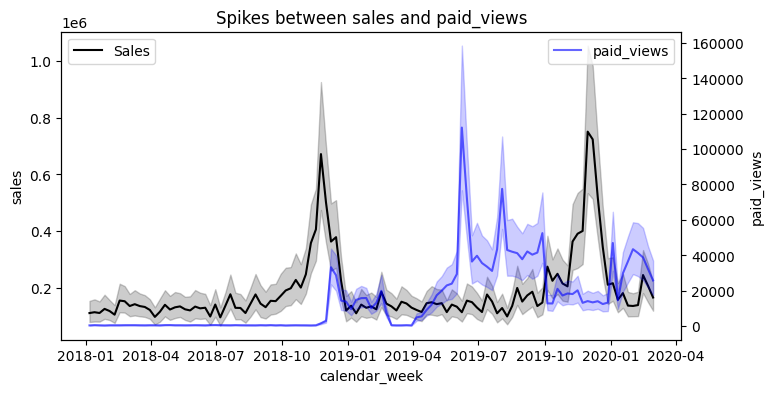

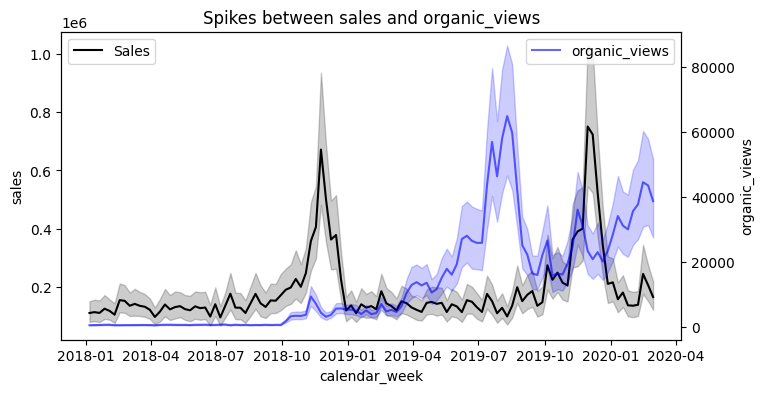

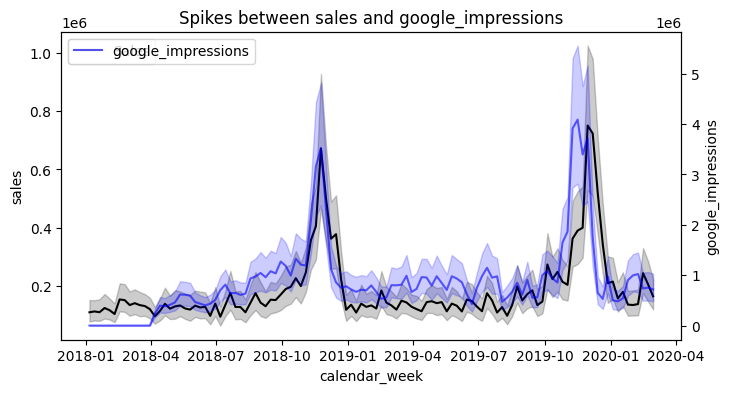

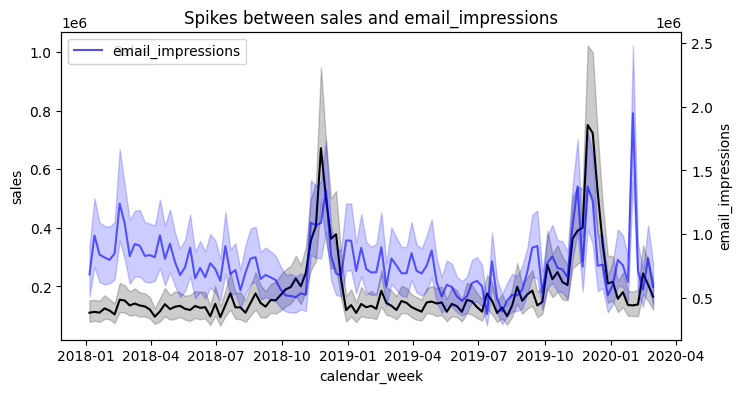

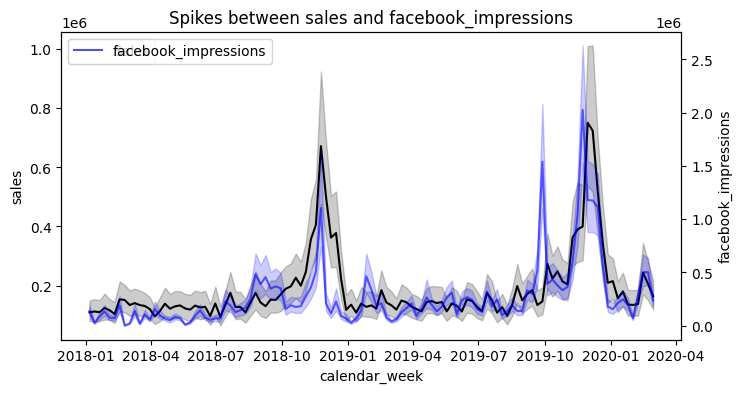

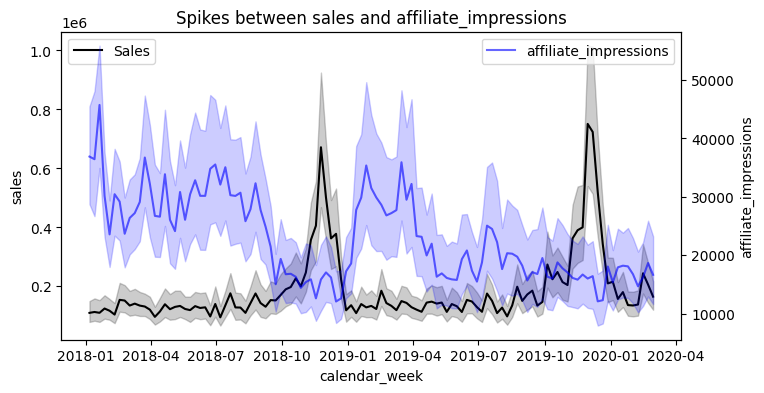

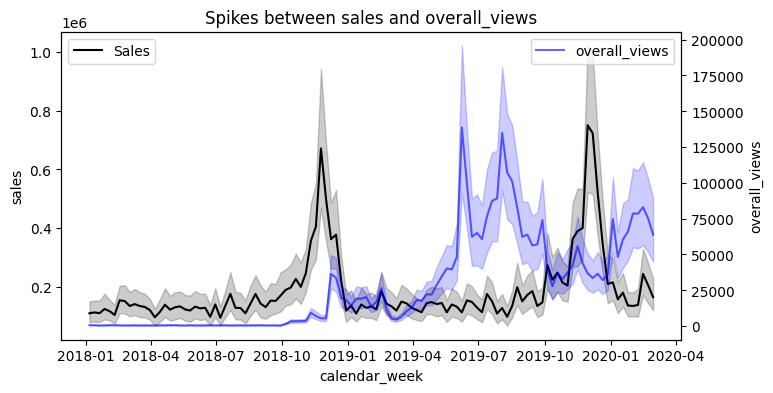

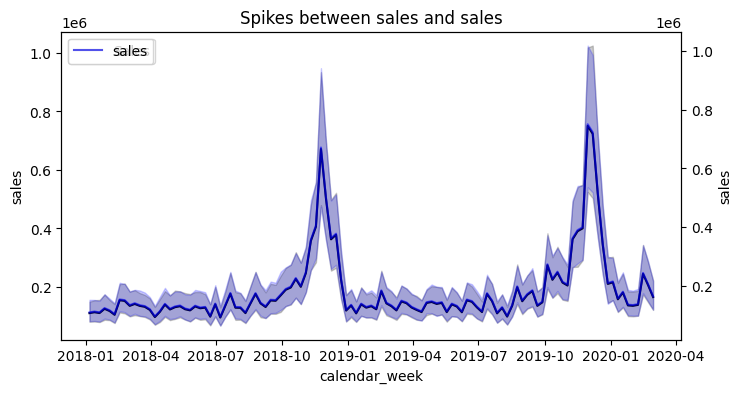

In [105]:
for column in numerical_columns:
    plot_averages(column)

#### Summary

In the figures above, the following can be seen 

* Sales and paid views do not show any strong correlation, as a spike in sales doesnt coincide with a spike in paid views.
* Organic views also dont have a strong correlation with sales although, there seems to be a lag effect where after the spike in the organic views, sales started ramping up as well 
* Google and Facebook impressions have very close correlations with sales with almost a 1:1 in terms of shape 
* Email impressions also looks to have a moderate correlation with sales
* Affiliate impressions has a weak correlation with sales and at times even looks messy however, there seems to be a slight lag, but is that because of affiliate impressions or other platforms 
* Overall views also has a lagging effect on sales with a spike around 2019-07 and then sales following suit, but with a time decay of almost 4 months, is it really a lag or just a spike that yielded nothing and a spike of sales which was functionally independent of overall views

Google impressions and facebook impressions might be searches since they correlated so strongly with sales, so what drives them to search then? 

##### Plotting a correlation matrix to compare the impact between google and facebook impressions

In [106]:
def correlation_heatmap(x,y):
    corr_matrix = df[[x,y]].corr(method = 'spearman')
    mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
    plt.figure(figsize = (8,6))
    sns.heatmap(corr_matrix,mask = mask, annot = True, cmap = 'coolwarm', center = 0)
    plt.title(f'Correlation heatmap between {x} and {y}')
    plt.show()

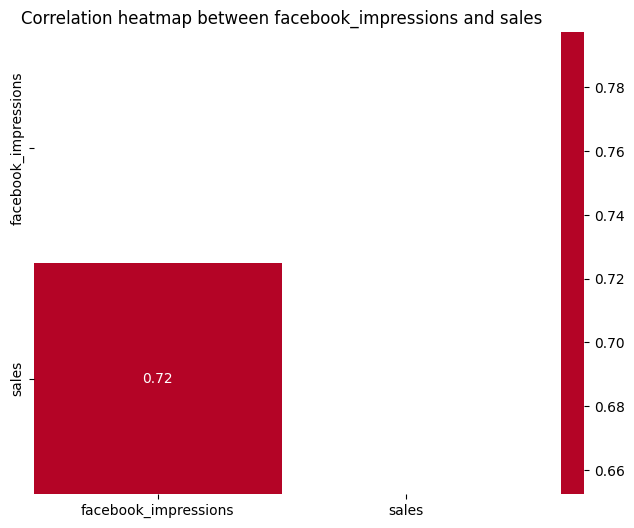

In [107]:
correlation_heatmap('facebook_impressions','sales')

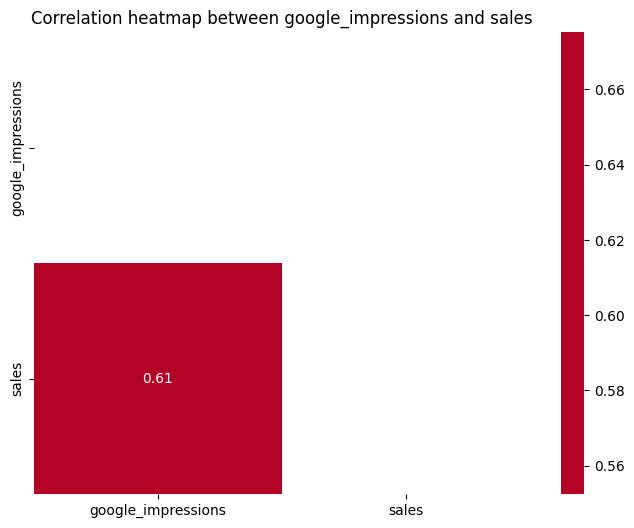

In [108]:
correlation_heatmap('google_impressions', 'sales')

###### Summary: 

- Facebook Impressions: Shows the strongest rank-order relationship with Sales ($\rho = 0.72$), suggesting it is a highly reliable driver of weekly revenue fluctuations.

- Google Impressions: While showing a more moderate correlation ($\rho = 0.61$), it handles significantly higher volume, peaking at $1.7 \times 10^7$ impressions. This indicates that Google is likely the primary "Reach" engine for the brand.

- Volume vs. Velocity: The data suggests a Lower Funnel synergy; Facebook acts as a high-precision conversion tool, while Google provides the massive scale necessary to sustain the business baseline.


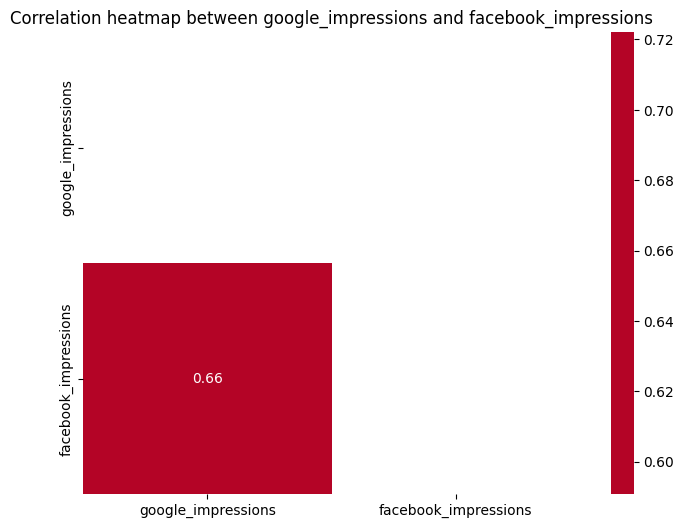

In [109]:
correlation_heatmap('google_impressions', 'facebook_impressions')

### Saturation between vehicles and Sales 

In this segment, I aim to check whether sales has a diminishing effect from different sources 

In [110]:
def plot_saturation_check(column):
    plt.figure(figsize=(10,6))
    sns.regplot(x = column, y = 'sales', data = df, 
                lowess = True, scatter_kws={
                    'color' : 'red'
                })
    plt.title(f"Saturation check {column} vs sales")
    plt.show()

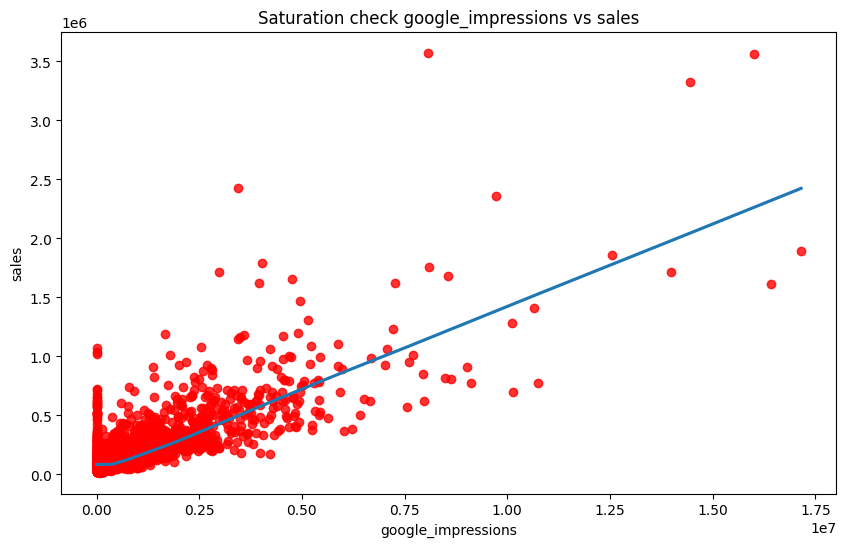

In [111]:
plot_saturation_check('google_impressions')

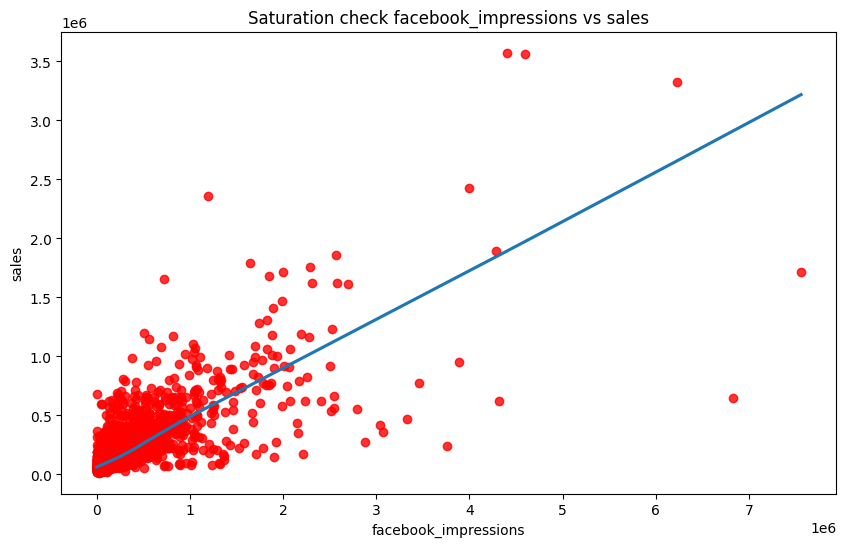

In [112]:
plot_saturation_check('facebook_impressions')

#### Summary

* Views grow in tandem with sales, there are outliers but the overall trend is upward. There doesnt seem to be a saturation point when the trend line starts becoming more horizontal

* This suggests an under saturation with potential for more sales by an increase of marketing volume 

* There are also spikes that dont confer to the existing trend, these spikes may be due to date correlations i.e christmas, new years etc 

* Once again, the correlations between facebook and google impressions with sales are so perfect that it leads me to wonder if this is just demand capture not generation

### Cross Correlation checking

In [113]:
def check_cross_corr(column, target = 'sales', max_lags = 8):
    lags = range(max_lags + 1)
    corrs = [df[target].corr(df[column].shift(l)) for l in lags]

    plt.figure(figsize = (10,8))
    plt.bar(lags, corrs, color = 'skyblue')
    plt.axhline(0, color = 'black')
    plt.title(f'Cross correlation: {column} leading {target}')
    plt.xlabel('Weeks Lagged')
    plt.ylabel('Correlation Coefficient')
    plt.show()

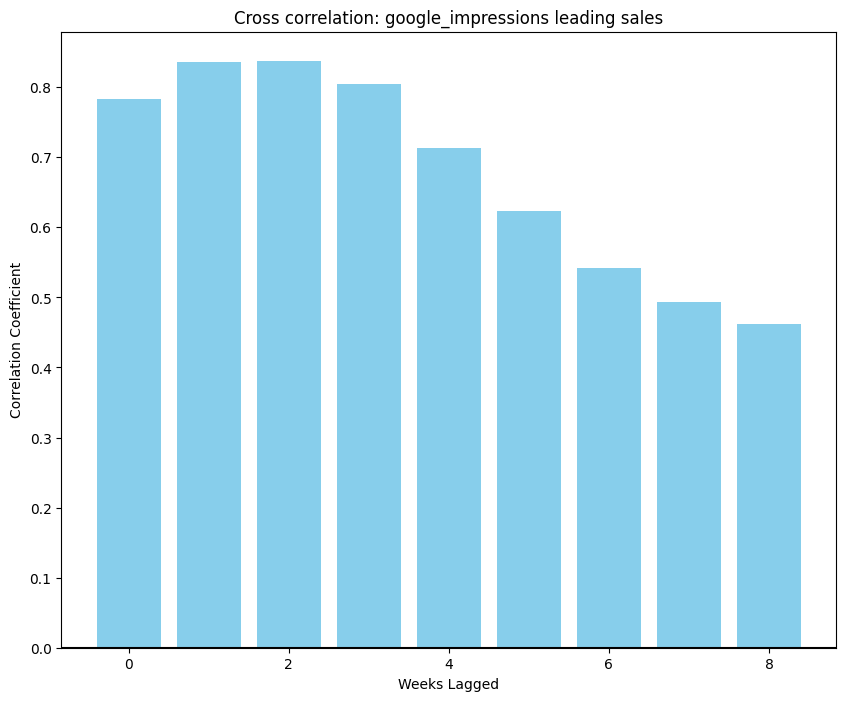

In [114]:
check_cross_corr('google_impressions')

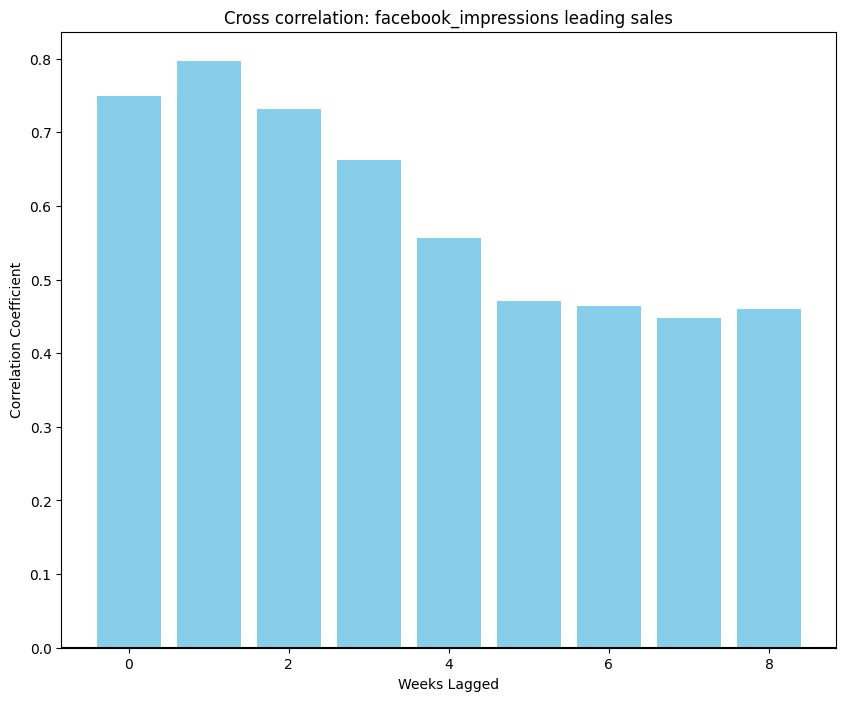

In [115]:
check_cross_corr('facebook_impressions')

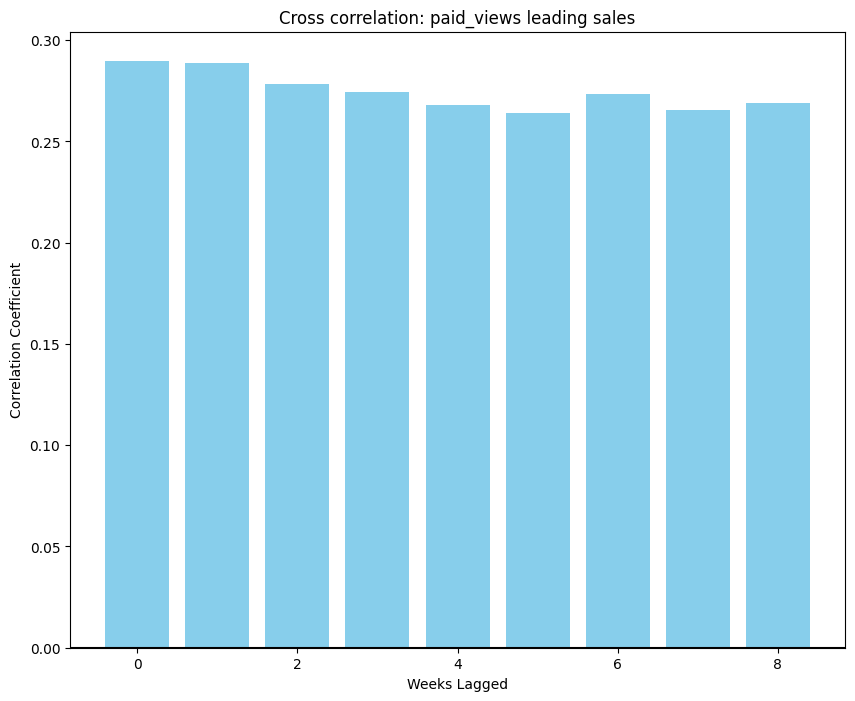

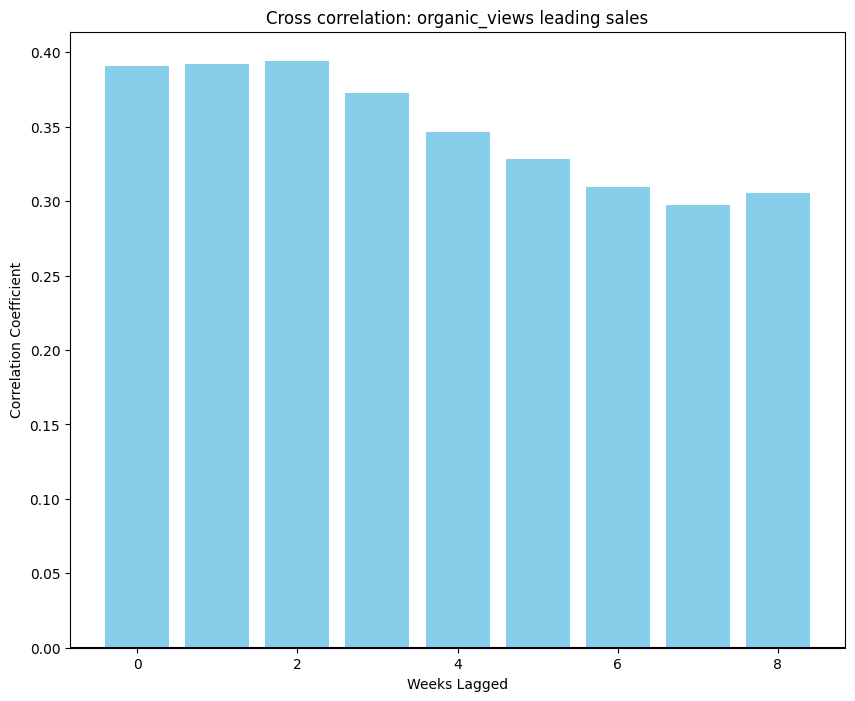

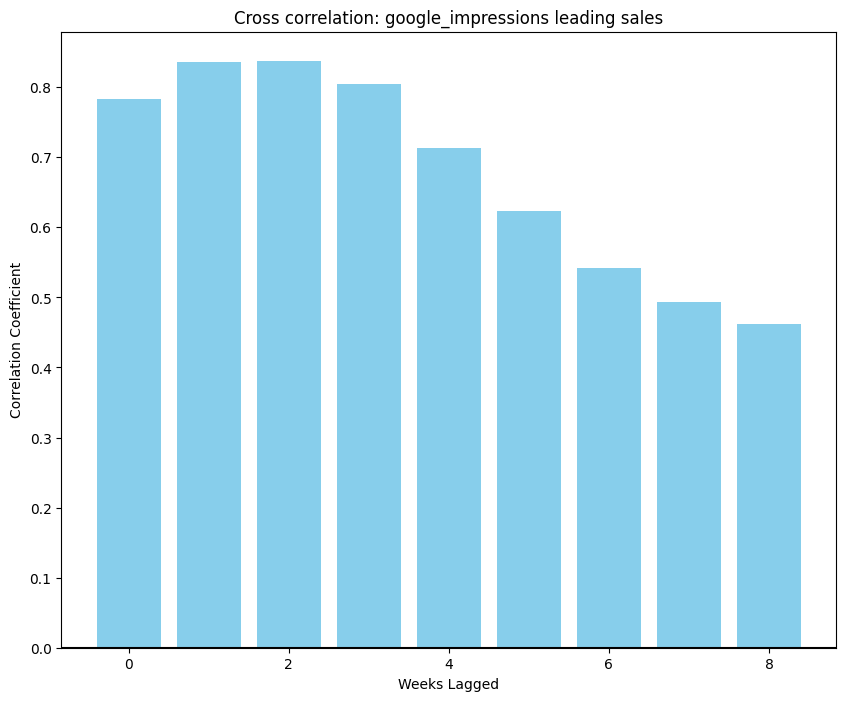

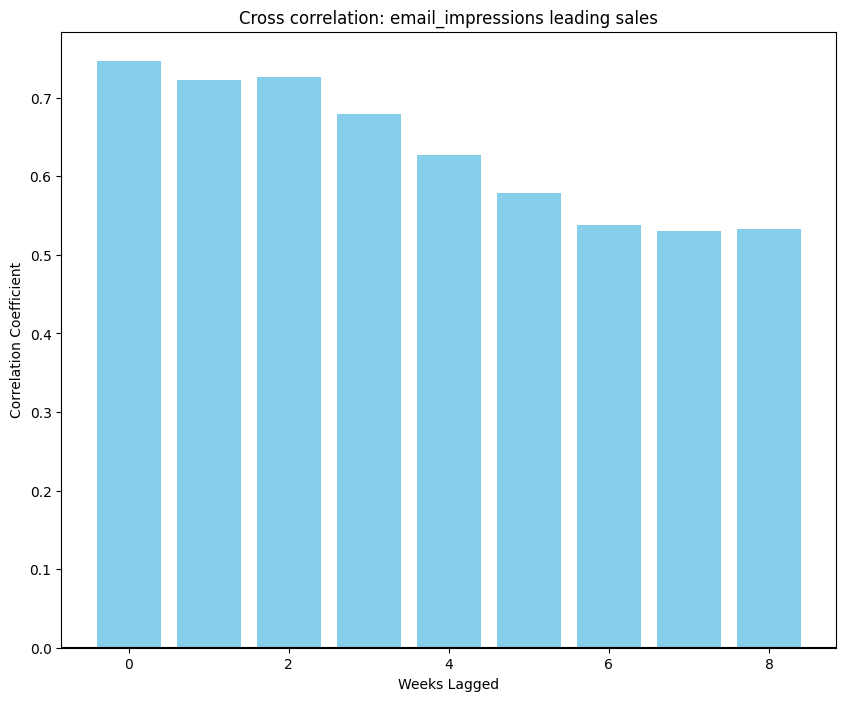

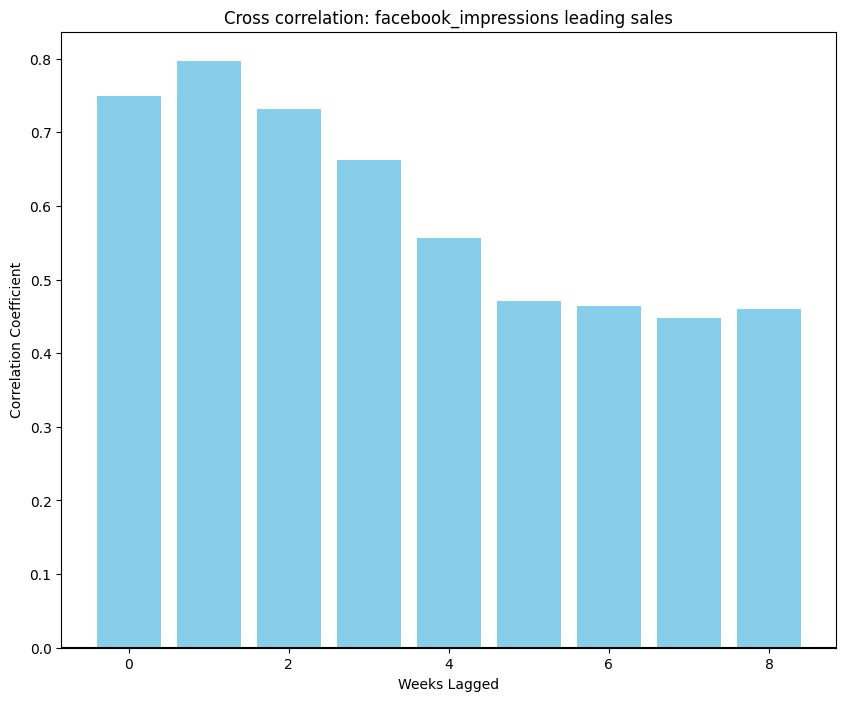

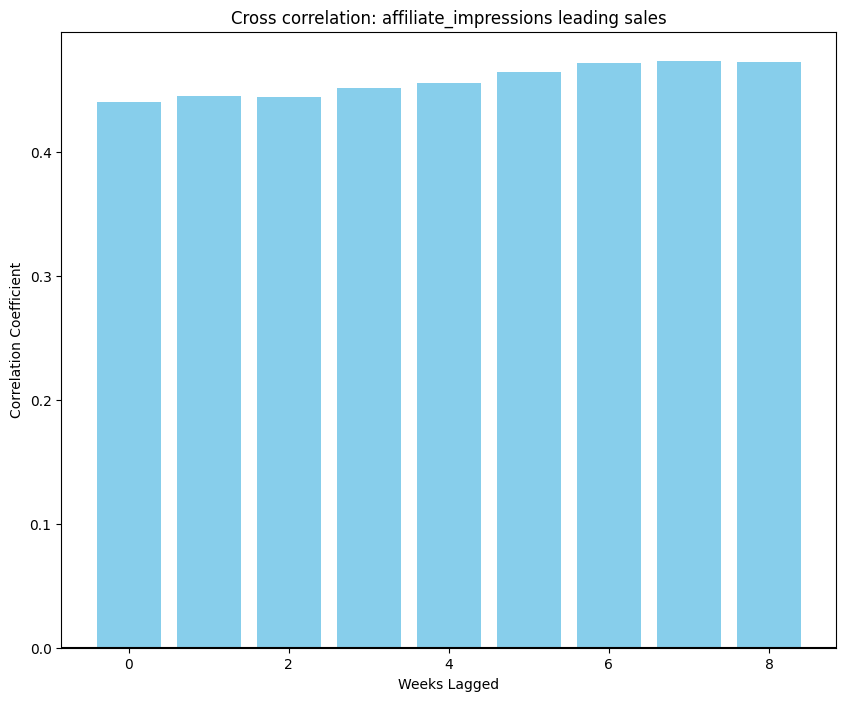

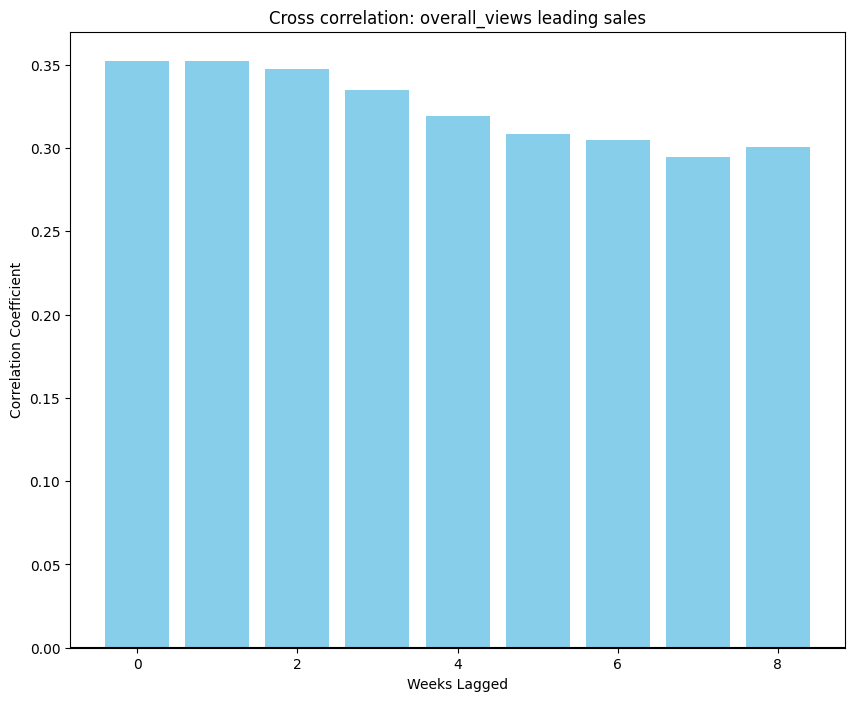

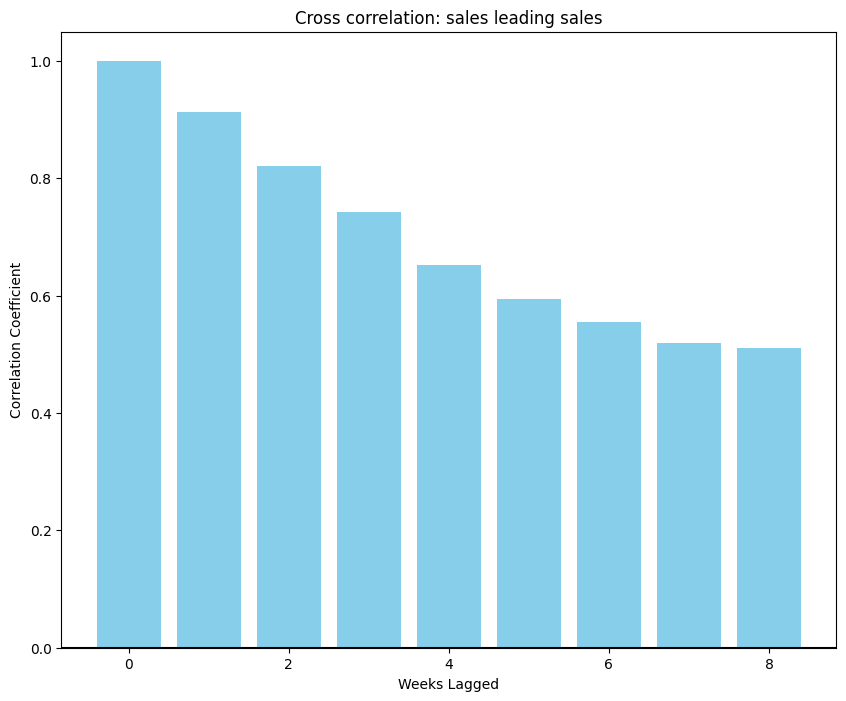

In [116]:
for column in numerical_columns:
    check_cross_corr(column)

#### Summary 

* Paid views has a tight bound in terms of correlation (within 5% for 8 weeks), however, the absolute correlation is only 0.30 MAX, this suggests a weak but stable correlative effect 

* Organic views tapers off slightly, especially post week 4, however organic views has a higher bound compared to paid views 

* Google impressions show a bell curve in terms of correlation i.e week 2 and 3 exhibit the highest correlation with sales at about 80% and then it tapers off gradually only having less than 50% correlation at week 7. This is great adstock lag 

* email impressions also shows a slight decay, however it never drops below the 50% mark in the 8 week period 

* Facebook impressions also show a bell curve kind of distribution (same as google impressions), however, it tapers off sharper than google with it getting below 50% at week 5 

* Affiliate impressions shows a very interesting pattern, it has a very tight bound however, its correlation grows within the 8 week period and has the highest correlation at the 8th week

* These show that facebook and google impressions arent just demand capture but also demand generative channels 

* Youtube paid views arent strong markers of sales

## Multivariate Analysis

### Adstock analysis

Quantifying the lingering effect in customer's heads numerically for model robusticity

In [117]:
def calculate_adstock(alpha, series):
    result = []
    for i in range (len(series)):
        variable = series[i]
        if i == 0:
            adstock = (variable)
            result.append(adstock)
        else: 
            adstock = (variable) + (alpha * result[i-1])
            result.append(adstock)
    
    return result

In [118]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

def find_best_alpha(series,target,train_ratio = 0.8):
    split = int(len(series) * train_ratio)
    series = np.array(series)
    target = np.array(target)

    x_train_raw = series[:split]
    x_test_raw = series[split:]

    y_train = target[:split]
    y_test = target[split:]

    alpha_candidates = np.arange(0.05,1.0,0.05)

    best_alpha = None
    best_rmse = float('inf')
    results = {}

    for a in alpha_candidates:
        adstock = calculate_adstock(a,series)

        adstock = np.array(adstock)

        x_train = adstock[:split].reshape(-1,1)
        x_test = adstock[split:].reshape(-1,1)

        model = Ridge(alpha=1.0)
        model.fit(x_train,y_train)
                  
        preds = model.predict(x_test)
        rmse = root_mean_squared_error(y_test,preds)

        results[a] = rmse

        if rmse < best_rmse:
            best_rmse = rmse
            best_alpha = a

    return best_alpha, results


In [119]:
fb_alpha, fb_scores = find_best_alpha(df['facebook_impressions'], df['sales'])
google_alpha, google_scores = find_best_alpha(df['google_impressions'], df['sales'])

print("Best Facebook Alpha:", fb_alpha)
print("Best Google Alpha:", google_alpha)


Best Facebook Alpha: 0.7000000000000001
Best Google Alpha: 0.7500000000000001


In [120]:
numerical_columns
marketing_channels = ['paid_views',
 'organic_views',
 'google_impressions',
 'email_impressions',
 'facebook_impressions',
 'affiliate_impressions',
 'overall_views',
 'trend']

In [121]:
df['trend'] = np.arange(len(df))

In [122]:
best_alphas = {}
for column in marketing_channels: 
    alpha,_ = find_best_alpha(df[column], df['sales'])
    print(f"{column} : {alpha}")
    df[f"{column}_adstock"] = calculate_adstock(alpha,df[column])
    


paid_views : 0.05
organic_views : 0.9000000000000001
google_impressions : 0.7500000000000001
email_impressions : 0.5
facebook_impressions : 0.7000000000000001
affiliate_impressions : 0.9500000000000001
overall_views : 0.05
trend : 0.05


In [123]:
df.head()

,division,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales,trend,paid_views_adstock,organic_views_adstock,google_impressions_adstock,email_impressions_adstock,facebook_impressions_adstock,affiliate_impressions_adstock,overall_views_adstock,trend_adstock
0,A,2018-01-06,392,422,408,349895,73580,12072,682,59417,0,392.000000,422.0000,408.000,349895.0000,73580.00,12072.000000,682.000000,0.000000
1,A,2018-01-13,787,904,110,506270,11804,9499,853,56806,1,806.600000,1283.8000,416.000,681217.5000,63310.00,20967.400000,887.100000,1.000000
2,A,2018-01-20,81,970,742,430042,52232,17048,759,48715,2,121.330000,2125.4200,1054.000,770650.7500,96549.00,36967.030000,803.355000,2.050000
3,A,2018-01-27,25,575,65,417745,78640,10207,942,72047,3,31.066500,2487.8780,855.500,803070.3750,146224.30,45325.678500,982.167750,3.102500
4,A,2018-02-03,565,284,295,408505,40561,5834,658,56235,4,566.553325,2523.0902,936.625,810040.1875,142918.01,48893.394575,707.108388,4.155125


In [124]:
df[['calendar_week', 'sales']].sort_values('sales' ,ascending = False).head()

,calendar_week,sales
213,2019-12-07,3575430
212,2019-11-30,3561292
159,2018-11-24,3322758
214,2019-12-14,2424124
160,2018-12-01,2363272


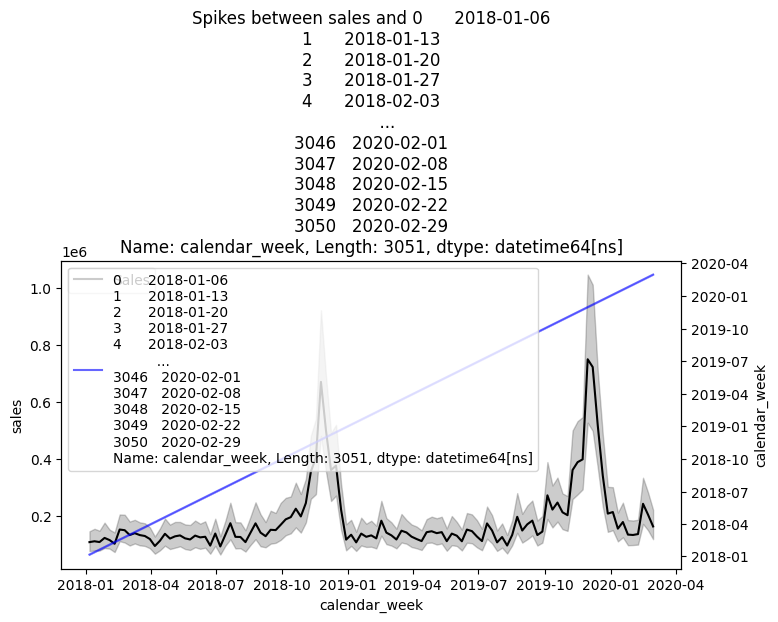

In [125]:
plot_averages(df['calendar_week'])

In [126]:
def create_dummies(df,column, prefix):
    dummies = pd.get_dummies(df[column], drop_first = True, prefix = prefix, dtype = 'int')
    df = pd.concat([df,dummies], axis = 1)
    df = df.drop(column, axis = 1)
    return df

In [127]:
df['month'] = df['calendar_week'].dt.month
df = create_dummies(df, 'month', 'month')

In [128]:
df.sort_values('sales', ascending = False)

,division,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
213,B,2019-12-07,62374,92268,8074788,4723940,4405999,63435,153916,3575430,...,0,0,0,0,0,0,0,0,0,1
212,B,2019-11-30,62934,100749,16001714,5153551,4599296,63817,162813,3561292,...,0,0,0,0,0,0,0,0,1,0
159,B,2018-11-24,6313,21117,14455623,4085227,6232118,52273,26417,3322758,...,0,0,0,0,0,0,0,0,1,0
214,B,2019-12-14,63230,101429,3454877,2821665,3994617,52322,164152,2424124,...,0,0,0,0,0,0,0,0,0,1
160,B,2018-12-01,12544,13893,9718005,5049751,1194281,53050,25608,2363272,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2178,T,2018-08-11,681,690,95833,134983,41134,3898,216,20377,...,0,0,0,0,0,1,0,0,0,0
2152,T,2018-02-10,162,203,338,164304,14800,4103,839,19899,...,0,0,0,0,0,0,0,0,0,0
2160,T,2018-04-07,568,766,33311,157738,38993,5102,149,18440,...,0,1,0,0,0,0,0,0,0,0
2228,T,2019-07-27,5075,11213,150223,96143,41479,3724,16039,18432,...,0,0,0,0,1,0,0,0,0,0


From the table above, divisions have a big correlation with sales. I will create dummies so these relationships can be retained in the dataset

In [129]:
df = create_dummies(df,'division','division')

In [130]:
df.head()

,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales,trend,...,division_Q,division_R,division_S,division_T,division_U,division_V,division_W,division_X,division_Y,division_Z
0,2018-01-06,392,422,408,349895,73580,12072,682,59417,0,...,0,0,0,0,0,0,0,0,0,0
1,2018-01-13,787,904,110,506270,11804,9499,853,56806,1,...,0,0,0,0,0,0,0,0,0,0
2,2018-01-20,81,970,742,430042,52232,17048,759,48715,2,...,0,0,0,0,0,0,0,0,0,0
3,2018-01-27,25,575,65,417745,78640,10207,942,72047,3,...,0,0,0,0,0,0,0,0,0,0
4,2018-02-03,565,284,295,408505,40561,5834,658,56235,4,...,0,0,0,0,0,0,0,0,0,0


## Predictive Modelling and Validation

### Feature encoding and Pre-processing

In [131]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()

In [132]:
marketing_channels

['paid_views',
 'organic_views',
 'google_impressions',
 'email_impressions',
 'facebook_impressions',
 'affiliate_impressions',
 'overall_views',
 'trend']

In [133]:
cols_to_scale = ['paid_views',
 'organic_views',
 'google_impressions',
 'email_impressions',
 'facebook_impressions',
 'affiliate_impressions',
 'overall_views',
 'trend',f'{column}_adstock']
adstock_cols = [c for c in df.columns if c.endswith('_adstock')]
cols_to_scale.extend(adstock_cols)

In [134]:
#df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [135]:
df.head()

,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales,trend,...,division_Q,division_R,division_S,division_T,division_U,division_V,division_W,division_X,division_Y,division_Z
0,2018-01-06,392,422,408,349895,73580,12072,682,59417,0,...,0,0,0,0,0,0,0,0,0,0
1,2018-01-13,787,904,110,506270,11804,9499,853,56806,1,...,0,0,0,0,0,0,0,0,0,0
2,2018-01-20,81,970,742,430042,52232,17048,759,48715,2,...,0,0,0,0,0,0,0,0,0,0
3,2018-01-27,25,575,65,417745,78640,10207,942,72047,3,...,0,0,0,0,0,0,0,0,0,0
4,2018-02-03,565,284,295,408505,40561,5834,658,56235,4,...,0,0,0,0,0,0,0,0,0,0


In [136]:
cols_to_scale

['paid_views',
 'organic_views',
 'google_impressions',
 'email_impressions',
 'facebook_impressions',
 'affiliate_impressions',
 'overall_views',
 'trend',
 'trend_adstock',
 'paid_views_adstock',
 'organic_views_adstock',
 'google_impressions_adstock',
 'email_impressions_adstock',
 'facebook_impressions_adstock',
 'affiliate_impressions_adstock',
 'overall_views_adstock',
 'trend_adstock']

In [137]:
drop_columns = ['paid_views',
 'organic_views',
 'google_impressions',
 'email_impressions',
 'facebook_impressions',
 'affiliate_impressions',
 'overall_views',
 'calendar_week',
 'trend']

In [138]:
ml_df = df.drop(columns = drop_columns)

In [139]:
ml_df.columns

Index(['sales', 'paid_views_adstock', 'organic_views_adstock',
       'google_impressions_adstock', 'email_impressions_adstock',
       'facebook_impressions_adstock', 'affiliate_impressions_adstock',
       'overall_views_adstock', 'trend_adstock', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'division_B', 'division_C',
       'division_D', 'division_E', 'division_F', 'division_G', 'division_H',
       'division_I', 'division_J', 'division_K', 'division_L', 'division_M',
       'division_N', 'division_O', 'division_P', 'division_Q', 'division_R',
       'division_S', 'division_T', 'division_U', 'division_V', 'division_W',
       'division_X', 'division_Y', 'division_Z'],
      dtype='object')

In [140]:
binary_columns = ['month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'division_B', 'division_C',
       'division_D', 'division_E', 'division_F', 'division_G', 'division_H',
       'division_I', 'division_J', 'division_K', 'division_L', 'division_M',
       'division_N', 'division_O', 'division_P', 'division_Q', 'division_R',
       'division_S', 'division_T', 'division_U', 'division_V', 'division_W',
       'division_X', 'division_Y', 'division_Z']

In [141]:
x = ml_df.drop(columns = 'sales')
y = ml_df['sales']

In [142]:
df.to_csv(f"../data/processed/ml_df.csv")

### Model Selection

In [143]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression,Ridge,Lasso,LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def model_evaluation(x,y,model,k = 5):
    tscv = TimeSeriesSplit(n_splits=k,)

    rmses,maes,r2s = [],[],[]

    for train_index, test_index in tscv.split(x):
        x_train,x_test = x.iloc[train_index],x.iloc[test_index]
        y_train,y_test = y.iloc[train_index],y.iloc[test_index]

        model.fit(x_train,y_train)
        preds = model.predict(x_test)

        rmses.append(root_mean_squared_error(y_test,preds))
        maes.append(mean_absolute_error(y_test,preds))
        r2s.append(r2_score(y_test,preds))

    return {
        "AVG RMSE" : np.mean(rmses),
        "AVG MAE" : np.mean(maes),
        "AVG R2S" : np.mean(r2s)
    }


In [144]:
models = {
    "Ridge Regressor": Ridge(alpha = 1),
    "Lasso": Lasso(alpha = 0.1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state = 42),
    "Random Forest Regressor": RandomForestRegressor(random_state = 42)
}

#### Model R2S tests

In [145]:
results_for_df = []

for name, model in models.items():
    metrics = model_evaluation(x,y,model)
    metrics['model'] = name

    results_for_df.append(metrics)

comparison_df = pd.DataFrame(results_for_df)

c:\Users\SOLOMON\Desktop\TWOL\Python stuff\Tutorial Stuff\Data science\Data science from scratch projects\Marketing Mix Modelling\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0856492244156537e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\SOLOMON\Desktop\TWOL\Python stuff\Tutorial Stuff\Data science\Data science from scratch projects\Marketing Mix Modelling\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.4335556793000865e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\SOLOMON\Desktop\TWOL\Python stuff\Tutorial Stuff\Data science\Data science from scratch projects\Marketing Mix Modelling\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1189140554907198e-17.
  return linalg.so

In [146]:
comparison_df

,AVG RMSE,AVG MAE,AVG R2S,model
0,137077.537310,116682.312482,0.004396,Ridge Regressor
1,862008.650766,794318.229371,-37.691501,Lasso
2,73919.773168,46900.349426,0.731116,Gradient Boosting Regressor
3,68979.697747,45565.724362,0.779713,Random Forest Regressor


C:\Users\SOLOMON\AppData\Local\Temp\ipykernel_9552\2928045840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


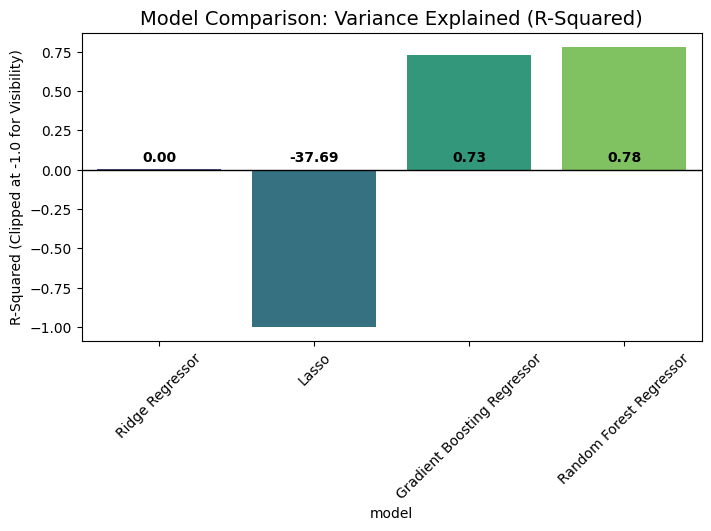

In [147]:
comparison_plot_df = comparison_df.copy()
comparison_plot_df['R2_visual'] = comparison_plot_df['AVG R2S'].clip(lower = -1)

plt.figure(figsize = (8,4))
sns.barplot(
    x = 'model', 
    y = 'R2_visual',
    data = comparison_plot_df,
    palette = 'viridis'
)
plt.axhline(0, color = 'black', lw=1)
plt.title('Model Comparison: Variance Explained (R-Squared)', fontsize=14)
plt.ylabel('R-Squared (Clipped at -1.0 for Visibility)')
plt.xticks(rotation=45)

for i, v in enumerate(comparison_plot_df['AVG R2S']):
    plt.text(i, 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.show()

##### Summary

* Both the Ridge regressor and the Lasso regressors performed badly on this data set with the ridge regressor having a score of 0.38 and the Lasso regressor havin a remarkable score of -37.68 

* Ensemble models had a better time of it with the Gradient boosting regressor coming out at 0.73 and the random forest regressor pipping it and coming out at 0.78

* Following the performances above, the Random Forest Regressor will be picked as the model of choice

In [148]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [149]:
def split_data(x,y):
    split_point = int(len(x) * 0.8)
    x_train = x.iloc[:split_point]
    x_test = x.iloc[split_point:]
    y_train = y.iloc[:split_point]
    y_test = y.iloc[split_point:]

    return x_train,x_test,y_train,y_test

In [150]:
def model_training(model,x,y):
    x_train,x_test,y_train,y_test = split_data(x,y)
    model.fit(x_train,y_train)
    return model

In [151]:
rf_model = model_training(rf_model,x,y)

### Feature Importance using SHAP

In [152]:
import shap

In [153]:
shap.initjs()

In [154]:

x_train,x_test,y_train,y_test = split_data(x,y)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)
shap_explainer = explainer(x_test)



In [155]:
expected = explainer.expected_value

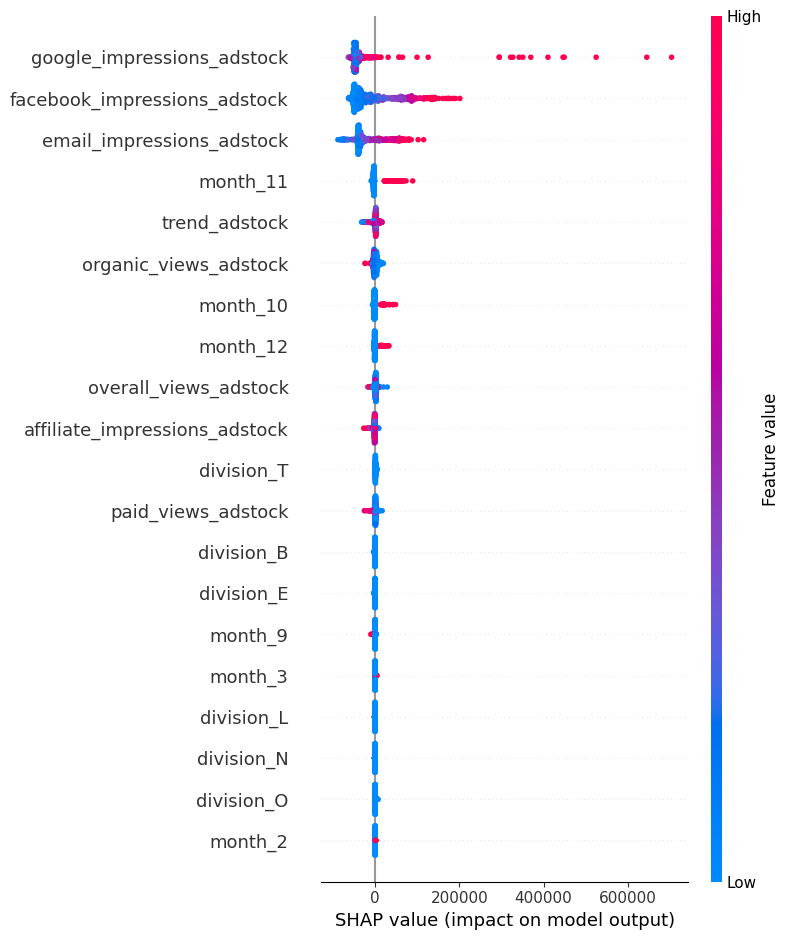

In [156]:
summary = shap.summary_plot(shap_values = shap_values, features = x_test)

#### Summary

* Google impressions have the most effect with respect to sales with facebook impressions trailing behind 
* the calendar month of November also has a significant positive impact on sales, likely reflecting the peak shopping season or year-end spikes in consumer activity. 

## Model Export 


In [157]:
columns = x.columns.tolist()

In [158]:
import joblib
model_path = f'../models/MMM Random forest model.pkl'
feature_path = f'../models/feature_names.pkl'
scaler_path = '../models/scaler.pkl'

model = joblib.dump(rf_model,model_path)    
features = joblib.dump(columns,feature_path)

In [162]:
print(columns)

['paid_views_adstock', 'organic_views_adstock', 'google_impressions_adstock', 'email_impressions_adstock', 'facebook_impressions_adstock', 'affiliate_impressions_adstock', 'overall_views_adstock', 'trend_adstock', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'division_B', 'division_C', 'division_D', 'division_E', 'division_F', 'division_G', 'division_H', 'division_I', 'division_J', 'division_K', 'division_L', 'division_M', 'division_N', 'division_O', 'division_P', 'division_Q', 'division_R', 'division_S', 'division_T', 'division_U', 'division_V', 'division_W', 'division_X', 'division_Y', 'division_Z']
